# Model Building: Hardware-OS Compatibility Classifier

This notebook trains and evaluates the core machine learning model used in the
Campus Spatial Decision Support System: a **Random Forest classifier** that
predicts whether a given machine is compatible with a given operating system,
based on six hardware/OS-requirement fit criteria.

This model is not meant to outperform a hand-written rule (the ground truth
label is, in fact, deterministically derived from such a rule) -- its purpose
is to give the SHAP explainability layer a trained model to generate
feature-contribution explanations from, since SHAP requires a model, not a
static rule, to attribute contributions.

**Pipeline:** Data Loading -> Feature Engineering -> Train/Test Split ->
Model Training -> Evaluation -> Visualization -> Model Saving


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, roc_curve
)

sys.path.append(str(Path.cwd().parent / "backend" / "mcdm"))
from topsis_ranker import TOPSISRanker, CRITERIA_ORDER, _ratio_fit, _tpm_fit, _secure_boot_fit

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Data Loading

We load the real hardware inventory (500 machines) and OS requirements matrix
(67 operating systems) from the project's dataset.


In [2]:
DATA_DIR = Path.cwd().parent / "data"

hardware = pd.read_csv(DATA_DIR / "hardware_inventory.csv")
os_requirements = pd.read_csv(DATA_DIR / "os_requirements.csv")

print(f"Hardware inventory: {hardware.shape[0]} machines, {hardware.shape[1]} attributes")
print(f"OS requirements: {os_requirements.shape[0]} operating systems")
hardware.head()


Hardware inventory: 500 machines, 19 attributes
OS requirements: 67 operating systems


,asset_id,block,lab,latitude,longitude,cpu_model,cpu_generation,cpu_cores,cpu_clock_ghz,ram_gb,storage_type,storage_gb,gpu,tpm_version,secure_boot_support,purchase_year,current_os,architecture,last_updated
0,PC-0001,Admin,Programming Lab,11.152094,79.490301,Intel Core i3-6100,6,2,3.7,8,SSD,256,AMD Radeon Vega,NaN,False,2018,Windows 11,x64,2026-06-01
1,PC-0002,Library,CAD Lab,11.145161,79.470796,Intel Core i3-6100,6,2,3.7,4,HDD,500,Integrated,NaN,False,2025,Windows 11,x64,2026-06-01
2,PC-0003,Block D,AI Lab,11.140208,79.474664,Intel Core i7-9700,9,8,3.0,4,SSD,256,NVIDIA GTX 1050,NaN,False,2018,Ubuntu 22.04,x64,2026-06-01
3,PC-0004,Block A,CAD Lab,11.154214,79.491892,Intel Core i3-6100,6,2,3.7,8,SSD,256,AMD Radeon Vega,2.0,True,2018,Ubuntu 24.04,x64,2026-06-01
4,PC-0005,Block D,Programming Lab,11.147321,79.491137,AMD Ryzen 3 3200G,3,4,3.6,32,SSD,256,Integrated,2.0,True,2020,Ubuntu 24.04,x64,2026-06-01


## 2. Feature Engineering

For every (machine, OS) pair, we compute six "fit" criteria comparing the
machine's hardware against that OS's minimum requirements:

- **RAM fit**, **Storage fit**, **CPU core fit**, **CPU clock fit**: ratio of
  actual to required, capped at 2.0x (so machines vastly exceeding a
  requirement don't dominate the scale)
- **TPM fit**, **Secure Boot fit**: graded satisfaction scores, since these
  are pass/fail security requirements rather than continuous specs

The ground-truth label (`compatible`) is 1 only if *every* hard requirement
is genuinely met -- this is what the model learns to predict.


In [3]:
def is_hard_compatible(asset_row, os_row) -> int:
    if asset_row["ram_gb"] < os_row["min_ram_gb"]:
        return 0
    if asset_row["storage_gb"] < os_row["min_storage_gb"]:
        return 0
    if asset_row["cpu_cores"] < os_row["min_cpu_cores"]:
        return 0
    if asset_row["cpu_clock_ghz"] < os_row["min_clock_ghz"]:
        return 0
    if pd.notna(os_row["tpm_required"]):
        if pd.isna(asset_row["tpm_version"]) or asset_row["tpm_version"] < os_row["tpm_required"]:
            return 0
    if bool(os_row["secure_boot_required"]) and not bool(asset_row["secure_boot_support"]):
        return 0
    return 1


def build_dataset(hardware_df, os_df):
    ranker = TOPSISRanker()
    rows = []
    for _, asset_row in hardware_df.iterrows():
        compatible_os = ranker._compatible_os(asset_row["architecture"])
        for _, os_row in compatible_os.iterrows():
            features = [
                _ratio_fit(asset_row["ram_gb"], os_row["min_ram_gb"]),
                _ratio_fit(asset_row["storage_gb"], os_row["min_storage_gb"]),
                _ratio_fit(asset_row["cpu_cores"], os_row["min_cpu_cores"]),
                _ratio_fit(asset_row["cpu_clock_ghz"], os_row["min_clock_ghz"]),
                _tpm_fit(asset_row["tpm_version"], os_row["tpm_required"]),
                _secure_boot_fit(asset_row["secure_boot_support"], os_row["secure_boot_required"]),
            ]
            label = is_hard_compatible(asset_row, os_row)
            rows.append(features + [label, asset_row["asset_id"], os_row["os_id"]])

    return pd.DataFrame(rows, columns=CRITERIA_ORDER + ["compatible", "asset_id", "os_id"])


df = build_dataset(hardware, os_requirements)
print(f"Built dataset: {df.shape[0]} (machine, OS) pairs, {df.shape[1]} columns")
df.head()


Built dataset: 33500 (machine, OS) pairs, 9 columns


,ram_fit,storage_fit,cpu_cores_fit,cpu_clock_fit,tpm_fit,secure_boot_fit,compatible,asset_id,os_id
0,2.0,2.0,1.0,2.0,1.00,1.00,1,PC-0001,win10
1,2.0,2.0,1.0,2.0,0.15,0.15,0,PC-0001,win11
2,2.0,2.0,1.0,2.0,1.00,1.00,1,PC-0001,ubuntu2404
3,2.0,2.0,1.0,2.0,1.00,1.00,1,PC-0001,ubuntu2204
4,2.0,2.0,1.0,2.0,1.00,1.00,1,PC-0001,kubuntu2404


## 3. Class Distribution

Before training, let's look at how balanced our target label is.

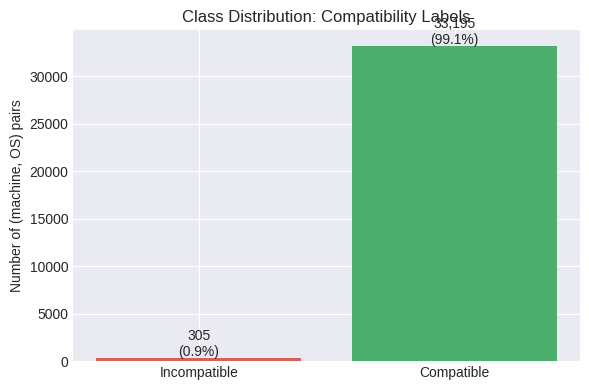

Note: only 0.9% of pairs are incompatible -- reflecting a dataset skewed toward reasonably modern hardware, with incompatibility concentrated mainly in Windows 11's TPM 2.0 requirement against older machines.


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['compatible'].value_counts()
labels = ['Incompatible', 'Compatible']
colors = ['#d9605a', '#4caf6d']
ax.bar(labels, [counts.get(0, 0), counts.get(1, 0)], color=colors)
ax.set_ylabel('Number of (machine, OS) pairs')
ax.set_title('Class Distribution: Compatibility Labels')
for i, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
    ax.text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120)
plt.show()

print(f"Note: only {counts.get(0,0)/len(df)*100:.1f}% of pairs are incompatible -- "
      f"reflecting a dataset skewed toward reasonably modern hardware, with "
      f"incompatibility concentrated mainly in Windows 11's TPM 2.0 requirement "
      f"against older machines.")


## 4. Train/Test Split

We hold out 20% of the data, stratified by class to preserve the class ratio in both splits.

In [5]:
X = df[CRITERIA_ORDER]
y = df['compatible']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")


Training set: 26800 samples
Test set:     6700 samples


## 5. Model Training

A Random Forest classifier with 200 trees, balanced class weights to account for the class imbalance shown above.

In [6]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
)
model.fit(X_train, y_train)
print("Model trained.")
print(model)


Model trained.
RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=200,
                       random_state=42)


## 6. Evaluation

In [7]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC:  {auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Incompatible', 'Compatible']))


Accuracy: 1.0000
ROC-AUC:  1.0000

              precision    recall  f1-score   support

Incompatible       1.00      1.00      1.00        61
  Compatible       1.00      1.00      1.00      6639

    accuracy                           1.00      6700
   macro avg       1.00      1.00      1.00      6700
weighted avg       1.00      1.00      1.00      6700



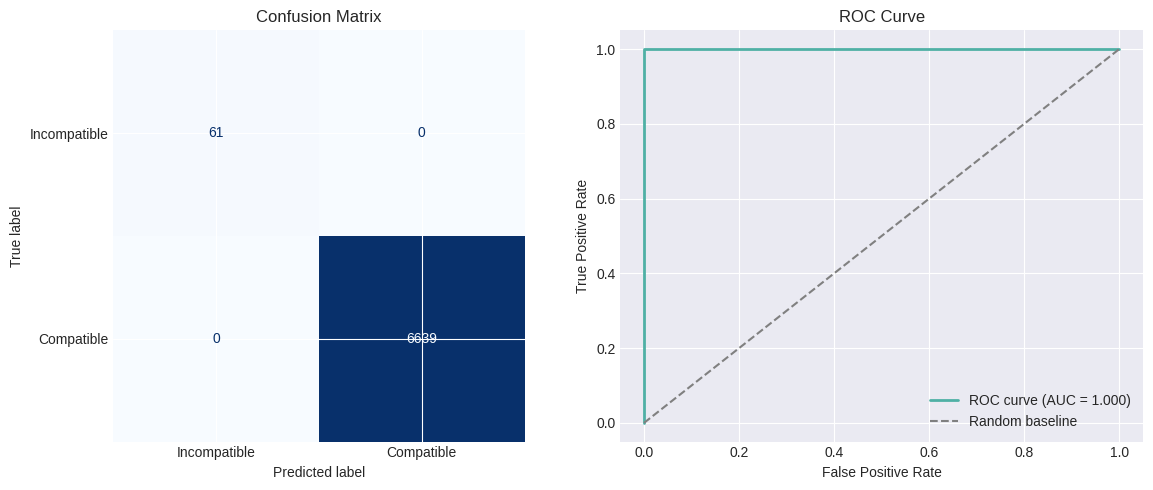

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Incompatible', 'Compatible'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})', color='#4fb0a5', linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('confusion_matrix_roc.png', dpi=120)
plt.show()


**A note on the near-perfect accuracy**: this is expected, not a sign the model is
overfitting or leaking data. The ground-truth label is a *deterministic function*
of the same six input features (see `is_hard_compatible` above) -- the model is
learning to approximate a known rule, not making a genuinely uncertain prediction.
Its value is not raw predictive accuracy but that it gives the SHAP
explainability layer (used elsewhere in this project) a trained model to
generate feature-contribution explanations from.


## 7. Feature Importance

Which criteria does the model rely on most, in aggregate, across all training examples?

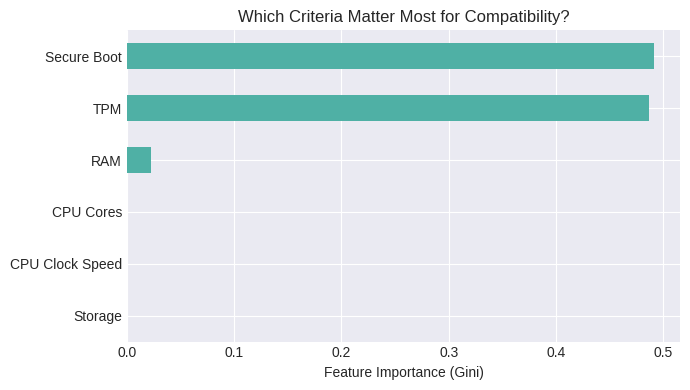

In [9]:
importances = pd.Series(model.feature_importances_, index=CRITERIA_ORDER).sort_values()

display_names = {
    'ram_fit': 'RAM', 'storage_fit': 'Storage', 'cpu_cores_fit': 'CPU Cores',
    'cpu_clock_fit': 'CPU Clock Speed', 'tpm_fit': 'TPM', 'secure_boot_fit': 'Secure Boot',
}
importances.index = [display_names[i] for i in importances.index]

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color='#4fb0a5')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Which Criteria Matter Most for Compatibility?')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()


## 8. Saving the Model

The trained model is saved so it can be loaded directly by the production API
(`backend/xai/shap_explainer.py`) without retraining.


In [10]:
MODEL_OUT = Path.cwd().parent / "backend" / "xai" / "saved_models" / "compatibility_classifier.joblib"
MODEL_OUT.parent.mkdir(exist_ok=True, parents=True)
joblib.dump(model, MODEL_OUT)
print(f"Model saved to: {MODEL_OUT}")

df.to_csv(Path.cwd().parent / "backend" / "xai" / "saved_models" / "training_dataset.csv", index=False)
print("Training dataset saved alongside it for reproducibility.")


Model saved to: /home/claude/campus-dss/backend/xai/saved_models/compatibility_classifier.joblib
Training dataset saved alongside it for reproducibility.


## 9. Summary

| Metric | Value |
|---|---|
| Training samples | See output above |
| Test samples | See output above |
| Test accuracy | See output above |
| ROC-AUC | See output above |

This model is one component of the larger Campus Spatial Decision Support
System, feeding into the SHAP-based explanation layer that produces
human-readable compatibility explanations (see `backend/xai/shap_explainer.py`
and `evaluation/EVALUATION_SUMMARY.md` for how this fits into the full,
end-to-end evaluated system).
